In [111]:
import os
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.plotting as ppplot
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point

# plotting convenience
%matplotlib inline
plt.rcParams.update({"figure.figsize": (10,6)})


# Define the data directory, as data folder in the parent OXENERGYMScPython directory
DATA_DIR = os.path.join("..", "Data")


## Import Data

 #2 Load core dataframes used in the notebook

In [112]:
# Update filenames to match your local files
gens_df = pd.read_csv(os.path.join(DATA_DIR, "UK_2025_gen_above100MW_EPSG4326 (1).csv"))  # example name
print(gens_df.head())
# If your notebook already loaded equivalent objects, comment these lines out and reuse them

   id  Name Fueltype      Technology  Capacity (MW)      lat     lon
0  37  Sloy    Hydro    Run-Of-River          153.0  56.2615 -4.7636
1  38  Foye    Hydro    Run-Of-River          320.0  57.2558 -4.4941
2  39  Ffes    Hydro    Run-Of-River          384.0  52.9808 -3.9686
3  40  Dino    Hydro    Run-Of-River         1728.0  53.1206 -4.1153
4  41  Crua    Hydro  Pumped Storage          440.0  56.4192 -5.0127


In [114]:
demand_region = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_V2 - Copy.xlsm"), sheet_name="MAIN DATA", skiprows=14, index_col=0)  # Demand by region
demand_region.head()


c:\Users\catz0911\AppData\Local\miniforge3\envs\GeoPower\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


,Name,Minor FLOP,Major FLOP,P(Gross),Q Gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Dx Storage Demand,Micro storage Demand
Elexon ID,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,Demand (MW),Demand (MVAR),Demand (MVAR),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Demand (MW),Demand (MW)
ABHA1,Abham,F6,F,329.998528,0.884376,-20.860707,60.717,212.007,0.988,1.917,97.242,0,0
ABNE_P,Abernethy,T4,T,38.702785,-0.688556,-2.012223,0.239,26.904,18.833,0.129,0,0,0
ABTH_1,Aberthaw,H2,H,174.13994,8.653586,-32.728783,0.54,108.668,0.545,0,29.537,0,0
ACTL_2,Acton Lane 66kV,A7,A,24.658002,-2.236142,-2.761841,0.142,5.303,0,0.279,0.363,0,0


In [115]:
# import grid supply point locations
gsp_locations = gpd.read_file("C:\\Users\\catz0911\\Downloads\\gsp_regions_20250109\\Proj_4326\\GSP_regions_4326_20250109.geojson")  # GSP lat lon mapping
gsp_locations.head()

,GSPs,GSPGroup,geometry
0,NETS,_N,"MULTIPOLYGON (((-4.46073 55.17672, -4.26086 55..."
1,CHAP,_N,"MULTIPOLYGON (((-3.07582 54.97528, -3.07616 54..."
2,BISW_1,_E,"MULTIPOLYGON (((-3.29887 52.4249, -3.29965 52...."
3,PORD,_N,"MULTIPOLYGON (((-4.25977 55.86125, -4.26002 55..."
4,BROR_P,_P,"MULTIPOLYGON (((-3.53593 58.15656, -3.53709 58..."


In [116]:
# import grid supply point locations
gsp_points = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_V2 - Copy.xlsm"), sheet_name="GSP info", skiprows=4, index_col=0)  # GSP lat lon mapping
gsp_points["geometry"] = gpd.points_from_xy(gsp_points.Longitude, gsp_points.Latitude)
gsp_points = gpd.GeoDataFrame(gsp_points, geometry="geometry", crs="EPSG:4326")
gsp_points[["Longitude", "Latitude"]] = gsp_points[["Longitude", "Latitude"]].astype(float)

# major flop is the first letter of major flop
gsp_points["Major FLOP"] = gsp_points["Minor FLOP"].astype(str).str[0]

# convert to british national grid
gsp_points = gsp_points.to_crs(epsg=27700)

In [117]:
gsp_points.head()

,GSP ID,GSP Group,Minor FLOP,Name,Latitude,Longitude,Comments,geometry,Major FLOP
NaN,ABHA1,_L,F6,Abham,50.471559,-3.729489,NaN,POINT (277366.77 64956.935),F
NaN,ABNE_P,_P,T4,Abernethy,56.339456,-3.293751,NaN,POINT (320119.11 717096.631),T
NaN,ABTH_1,_K,H2,Aberthaw,51.385210,-3.403318,NaN,POINT (302444.047 166064.259),H
NaN,ACTL_2,_H,A7,Acton Lane 66kV,51.534951,-0.257050,NaN,POINT (520984.73 183222.12),A
NaN,ACTL_C,_C,A7,Acton Lane 22kV,51.534951,-0.257050,NaN,POINT (520984.73 183222.12),A


In [118]:
# import GSP polygons as well in British National Grid coordinates 
gsp_polygons = gpd.read_file("C:\\Users\\catz0911\\Downloads\\gsp_regions_20250109\\Proj_4326\\GSP_regions_4326_20250109.geojson")
gsp_polygons.crs = "EPSG:4326"
gsp_polygons = gsp_polygons.to_crs(epsg=27700)


In [119]:
# Separate pipe-delimited GSPs into separate rows
gsp_polygons["GSPs"] = gsp_polygons["GSPs"].str.split("|")
gsp_polygons = gsp_polygons.explode("GSPs").reset_index(drop=True)

# Fill in missing Minor FLOP and Major FLOP data from gsp_points
# Drop the existing FLOP columns from the merge (they may have NaN values)
gsp_polygons = gsp_polygons.drop(columns=["GSP ID", "Major FLOP", "Minor FLOP"], errors="ignore")

# Merge again with gsp_points to get complete FLOP data
gsp_polygons = gsp_polygons.merge(
    gsp_points[["GSP ID", "Major FLOP", "Minor FLOP", "GSP Group"]], 
    left_on="GSPs", 
    right_on="GSP ID", 
    how="left"
)

In [120]:
gsp_polygons.head()

,GSPs,GSPGroup,geometry,GSP ID,Major FLOP,Minor FLOP,GSP Group
0,NETS,_N,"MULTIPOLYGON (((243392.631 589698.709, 255939....",NETS,S,S6,_N
1,CHAP,_N,"MULTIPOLYGON (((331236.338 565048.182, 331214....",CHAP,S,S6,_N
2,BISW_1,_E,"MULTIPOLYGON (((311775.048 281560.56, 311722.7...",BISW_1,L,L2,_E
3,PORD,_N,"MULTIPOLYGON (((258665.362 665428.688, 258649....",PORD,S,S5,_N
4,BROR_P,_P,"MULTIPOLYGON (((309710.615 919660.325, 309641....",BROR_P,T,T5,_P


## Group by Major FLOP

In [121]:
major_FLOP_polygons = gsp_polygons.dissolve(by="Major FLOP").reset_index()

In [122]:
# groupby major flop
demand_region_major_flop = demand_region.groupby("Major FLOP").agg({"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})

In [123]:
# add major flop polygons
demand_region_major_flop = gpd.GeoDataFrame(demand_region_major_flop.merge(major_FLOP_polygons[["Major FLOP", "GSP Group", "geometry"]],
                                                                      left_on="Major FLOP",
                                                                        right_on="Major FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")

#showing the full dataframe
demand_region_major_flop

,Major FLOP,P(Gross),Q Gross,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,GSP Group,geometry
0,A,9134.278885,1195.647333,530.148,1.017,3.452,717.33,_A,"MULTIPOLYGON (((499272 142548, 499230 142600, ..."
1,B,3497.82783,299.440241,1198.495,73.426,0.469,180.963,_H,"MULTIPOLYGON (((449470.92 102396.843, 449438.2..."
2,C,2144.666292,192.110474,923.545,239.613,0.474,676.853,_A,"MULTIPOLYGON (((532060.114 143491.058, 531951...."
3,D,2176.819603,92.612757,971.335,29.002,1.17,428.49,_H,"MULTIPOLYGON (((493191.034 206824.291, 493032...."
4,E,1258.536836,30.104401,1087.715,3.592,0.467,132.384,_L,"MULTIPOLYGON (((347800.463 88920.721, 346449.7..."
5,F,1635.689858,63.253742,1436.418,298.912,9.758,310.014,_L,"MULTIPOLYGON (((86209.974 11377.099, 86128.516..."
6,G,1882.996294,300.01668,1515.829,43.309,3.22,281.712,_L,"MULTIPOLYGON (((365026.999 134319.8, 365025.70..."
7,H,2129.232049,272.148944,1203.133,548.87,17.69,578.34,_K,"MULTIPOLYGON (((319884.02 172587.613, 319827.4..."
8,J,3286.903677,159.326134,2579.128,603.566,0.137,883.004,_A,"MULTIPOLYGON (((567823.549 206262.511, 567801...."
9,K,582.766968,52.364216,790.545,219.316,0,128.889,_B,"MULTIPOLYGON (((464051.666 344196.739, 464060...."


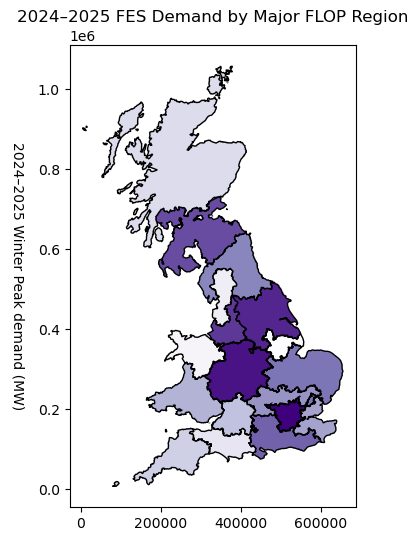

In [124]:
ax = demand_region_major_flop.plot(
    column="P(Gross)",
    cmap="Purples",
    legend=False,
    edgecolor="black"
)

# Get colorbar from the figure by searching for mappable
fig = ax.get_figure()
cbar = fig.axes[-1]   # last axis is the colorbar if it exists
cbar.set_ylabel("2024–2025 Winter Peak demand (MW)", rotation=270, labelpad=20)
ax.set_title("2024–2025 FES Demand by Major FLOP Region")
plt.show()

## Group by GSP Group

In [125]:
demand_region_major_flop.head()

,Major FLOP,P(Gross),Q Gross,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,GSP Group,geometry
0,A,9134.278885,1195.647333,530.148,1.017,3.452,717.33,_A,"MULTIPOLYGON (((499272 142548, 499230 142600, ..."
1,B,3497.82783,299.440241,1198.495,73.426,0.469,180.963,_H,"MULTIPOLYGON (((449470.92 102396.843, 449438.2..."
2,C,2144.666292,192.110474,923.545,239.613,0.474,676.853,_A,"MULTIPOLYGON (((532060.114 143491.058, 531951...."
3,D,2176.819603,92.612757,971.335,29.002,1.17,428.49,_H,"MULTIPOLYGON (((493191.034 206824.291, 493032...."
4,E,1258.536836,30.104401,1087.715,3.592,0.467,132.384,_L,"MULTIPOLYGON (((347800.463 88920.721, 346449.7..."


In [126]:
# dno regions can be downloaded as a separate file or following the process above and dissolving on GSP Group

# groupby GSP Group
demand_region_group_flop = demand_region_major_flop.dissolve(by="GSP Group", aggfunc={"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})



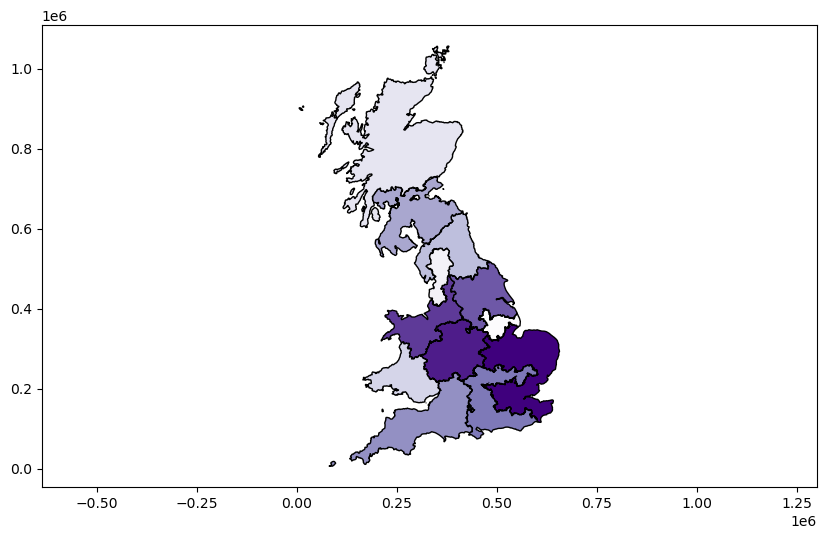

In [127]:
ax = demand_region_group_flop.plot(column="P(Gross)", cmap="Purples", legend=False, edgecolor="black")
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

### Embedded solar and wind generation

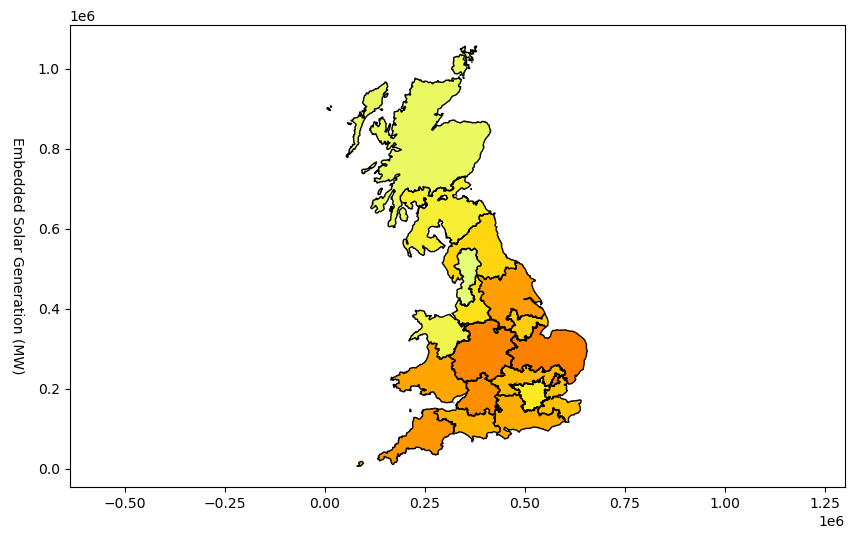

In [128]:
ax = demand_region_major_flop.plot(column="Embedded Solar", cmap="Wistia", legend=False, edgecolor="black")
# color bar label
cbar = ax.get_figure().get_axes()[-1]
cbar.set_ylabel("Embedded Solar Generation (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

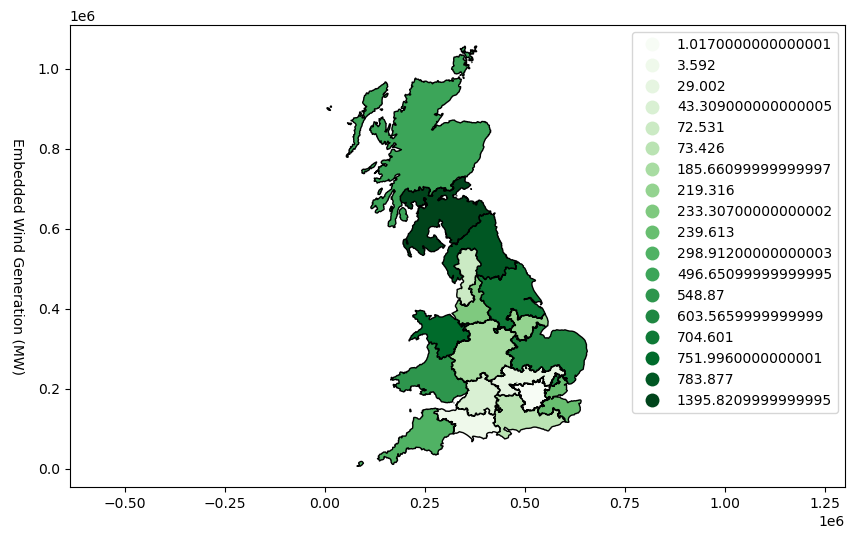

In [129]:
ax = demand_region_major_flop.plot(column="Embedded Wind", cmap="Greens", legend=True, edgecolor="black")
# color bar label
cbar = ax.get_figure().get_axes()[-1]
cbar.set_ylabel("Embedded Wind Generation (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

## Import generation data (Again)

In [130]:
gens_df = pd.read_csv(os.path.join(DATA_DIR, "UK_2025_gen_above100MW_EPSG4326 (1).csv"), index_col=0)
print(gens_df.shape)
# convert to geopandas using longitude and latitude columns
gen_gdf = gpd.GeoDataFrame(gens_df, geometry=gpd.points_from_xy(gens_df.lon, gens_df.lat), crs="EPSG:4326")

# remove gilbraltar 
gen_gdf = gen_gdf[gen_gdf.lat >= 40]

# convert to british national grid
gen_gdf = gen_gdf.to_crs(epsg=27700)

(118, 6)


In [131]:
# assign large_gen_gdf to nearest polygon of major_FLOP_polygons
gen_gdf = gpd.sjoin_nearest(
    gen_gdf, 
    major_FLOP_polygons[["Major FLOP", "geometry"]], 
    how="left"
)
    
# drop the index column created by sjoin
gen_gdf = gen_gdf.drop(columns=["index_right"], errors="ignore")

In [132]:
gen_gdf.shape

(118, 8)

In [133]:
gen_gdf.head()

,Name,Fueltype,Technology,Capacity (MW),lat,lon,geometry,Major FLOP
id,,,,,,,,
37,Sloy,Hydro,Run-Of-River,153.0,56.2615,-4.7636,POINT (228923.845 711102.499),T
38,Foye,Hydro,Run-Of-River,320.0,57.2558,-4.4941,POINT (249643.853 821104.04),T
39,Ffes,Hydro,Run-Of-River,384.0,52.9808,-3.9686,POINT (267928.79 344418.088),M
40,Dino,Hydro,Run-Of-River,1728.0,53.1206,-4.1153,POINT (258539.759 360247.612),M
41,Crua,Hydro,Pumped Storage,440.0,56.4192,-5.0127,POINT (214268.534 729293.732),T


In [134]:
# group by type and major flop
gen_grouped = gen_gdf.groupby(["Major FLOP", "Fueltype"]).agg({'Capacity (MW)': 'sum'})
gen_grouped

Capacity (MW)
Major FLOP Fueltype                    
A          Natural Gas           1267.0
B          Natural Gas           1465.0
           Wind                   400.0
C          Natural Gas           3990.0
           Solar                  378.3
           Wind                  1070.0
D          Natural Gas           1490.0
E          Natural Gas           1258.0
           Nuclear               5284.0
F          Natural Gas           1045.0
G          Natural Gas           1258.0
H          Natural Gas           4241.0
           Wind                   228.0
J          Natural Gas           4043.0
           Nuclear               1320.0
           Wind                  6959.8
K          Natural Gas           3633.0
           Wind                  1061.0
L          Natural Gas            236.0
M          Hydro                 2112.0
           Natural Gas           2015.0
           Wind                   576.0
N          Natural Gas           1855.0
           Wind                   254.0
P          Natural Gas           5462.0
           Solid Biomass         2718.0
           Wind                  1300.0
Q          Natural Gas            509.8
           Solid Biomass          299.0
           Wind                  5165.2
R          Nuclear               2676.0
S          Natural Gas           1008.0
           Nuclear               1370.0
           Wind                  3776.4
T          Hydro                  913.0
           Natural Gas           1653.0
           Wind                  4003.4

In [135]:
gen_grouped.xs('Wind', level='Fueltype')

,Capacity (MW)
Major FLOP,
B,400.0
C,1070.0
H,228.0
J,6959.8
K,1061.0
M,576.0
N,254.0
P,1300.0
Q,5165.2


In [136]:
large_wind_major_flop_polygons = gpd.GeoDataFrame(gen_grouped.xs('Wind', level='Fueltype').merge(major_FLOP_polygons[["Major FLOP", "GSP Group", "geometry"]],
                                                                      left_on="Major FLOP",
                                                                        right_on="Major FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")


<Axes: >

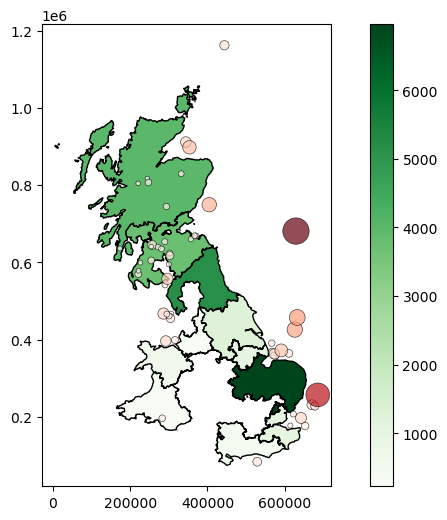

In [137]:
ax = large_wind_major_flop_polygons.plot(column="Capacity (MW)", cmap="Greens", legend=True, edgecolor="black")

# add points from gen_gdf with point size related to capacity
wind_gen = gen_gdf[gen_gdf["Fueltype"]=='Wind']
wind_gen.plot(
    ax=ax, 
    column="Capacity (MW)", 
    markersize=wind_gen["Capacity (MW)"] / 10,  # Scale factor to adjust size
    cmap="Reds",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5
)

In [138]:
# Aggregate demand and embedded resources by Major FLOP
# Group demand_region by Major FLOP and sum the relevant columns

# Ensure Major FLOP is a column in demand_region
if 'Major FLOP' not in demand_region.columns:
    demand_region = demand_region.reset_index()

# Select and aggregate columns for each Major FLOP
demand_by_major_flop = demand_region.groupby('Major FLOP').agg({
    'P(Gross)': 'sum',
    'Q Gross': 'sum',
    'Embedded Solar': 'sum',
    'Embedded Wind': 'sum',
    'Embedded Hydro': 'sum',
    'Embedded Other': 'sum'
}).reset_index()

# Rename columns for clarity
demand_by_major_flop = demand_by_major_flop.rename(columns={
    'P(Gross)': 'P Gross',
    'Q Gross': 'Q Net',
    'Embedded Solar': 'Embedded Solar',
    'Embedded Wind': 'Embedded Wind',
    'Embedded Hydro': 'Embedded Hydro',
    'Embedded Other': 'Embedded Other'
})

print('Aggregated demand and embedded resources by Major FLOP:')
print(f'Shape: {demand_by_major_flop.shape}')
print(f'Columns: {list(demand_by_major_flop.columns)}')
display(demand_by_major_flop)


Aggregated demand and embedded resources by Major FLOP:
Shape: (18, 7)
Columns: ['Major FLOP', 'P Gross', 'Q Net', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Embedded Other']


,Major FLOP,P Gross,Q Net,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other
0,A,9134.278885,1195.647333,530.148,1.017,3.452,717.33
1,B,3497.82783,299.440241,1198.495,73.426,0.469,180.963
2,C,2144.666292,192.110474,923.545,239.613,0.474,676.853
3,D,2176.819603,92.612757,971.335,29.002,1.17,428.49
4,E,1258.536836,30.104401,1087.715,3.592,0.467,132.384
5,F,1635.689858,63.253742,1436.418,298.912,9.758,310.014
6,G,1882.996294,300.01668,1515.829,43.309,3.22,281.712
7,H,2129.232049,272.148944,1203.133,548.87,17.69,578.34
8,J,3286.903677,159.326134,2579.128,603.566,0.137,883.004
9,K,582.766968,52.364216,790.545,219.316,0,128.889


In [139]:
# Create 400 kV buses at Major FLOP centroids and assign load/generation
bus_centroids = major_FLOP_polygons.copy()
bus_centroids['geometry'] = bus_centroids.geometry.centroid
bus_gdf = gpd.GeoDataFrame(bus_centroids[[ 'Major FLOP', 'geometry' ]].copy(), crs=major_FLOP_polygons.crs)
bus_gdf['x'] = bus_gdf.geometry.x
bus_gdf['y'] = bus_gdf.geometry.y

# Prepare load data (P(Gross), Q Gross) from demand_region_major_flop
loads = demand_region_major_flop.copy()
if 'Major FLOP' not in loads.columns:
    loads = loads.reset_index()
loads = loads[[ 'Major FLOP', 'P(Gross)', 'Q Gross' ]].copy()
bus_gdf = bus_gdf.merge(loads, on='Major FLOP', how='left')
bus_gdf['P(Gross)'] = bus_gdf['P(Gross)'].fillna(0)
bus_gdf['Q Gross'] = bus_gdf['Q Gross'].fillna(0)

# Aggregate generator capacity by Major FLOP from gen_grouped
try:
    gen_supply = gen_grouped.groupby(level='Major FLOP').sum().reset_index()
except Exception:
    gen_supply = gen_grouped.reset_index().groupby('Major FLOP').sum().reset_index()
gen_supply = gen_supply.rename(columns={'Capacity (MW)': 'Gen_Capacity_MW'})
bus_gdf = bus_gdf.merge(gen_supply[[ 'Major FLOP', 'Gen_Capacity_MW' ]], on='Major FLOP', how='left')
bus_gdf['Gen_Capacity_MW'] = bus_gdf['Gen_Capacity_MW'].fillna(0)

# Create a simple pandapower network and add buses, loads and static generators
net = pp.create_empty_network()
bus_index_map = {}
for _, row in bus_gdf.iterrows():
    b = pp.create_bus(net, vn_kv=400, name=str(row['Major FLOP']))
    bus_index_map[row['Major FLOP']] = b

# store geodata for plotting (pandapower plotting expects net.bus_geodata with x/y columns)
net.bus_geodata = pd.DataFrame({
    'x': bus_gdf['x'].values,
    'y': bus_gdf['y'].values
}, index=[bus_index_map[k] for k in bus_gdf['Major FLOP']])

# Add loads (assumes P(Gross) is in MW and Q Gross in MVar)
for _, row in bus_gdf.iterrows():
    b_idx = bus_index_map[row['Major FLOP']]
    if row['P(Gross)'] > 0:
        pp.create_load(net, bus=b_idx, p_mw=float(row['P(Gross)']), q_mvar=float(row['Q Gross']))
    # add aggregated generation as static generator
    if row['Gen_Capacity_MW'] > 0:
        pp.create_sgen(net, bus=b_idx, p_mw=float(row['Gen_Capacity_MW']))

# Summary outputs
print('Created', len(net.bus), 'buses at Major FLOP centroids')
display(bus_gdf[[ 'Major FLOP', 'x', 'y', 'P(Gross)', 'Q Gross', 'Gen_Capacity_MW' ]])
display(net)

C:\Users\catz0911\AppData\Local\Temp\ipykernel_27032\1776167430.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bus_gdf['P(Gross)'] = bus_gdf['P(Gross)'].fillna(0)
C:\Users\catz0911\AppData\Local\Temp\ipykernel_27032\1776167430.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bus_gdf['Q Gross'] = bus_gdf['Q Gross'].fillna(0)


Created 18 buses at Major FLOP centroids


,Major FLOP,x,y,P(Gross),Q Gross,Gen_Capacity_MW
0,A,519126.227731,185834.508354,9134.278885,1195.647333,1267.0
1,B,491949.118837,131058.924790,3497.827830,299.440241,1865.0
2,C,586361.432199,167957.539278,2144.666292,192.110474,5438.3
3,D,496718.559462,225888.034934,2176.819603,92.612757,1490.0
4,E,361513.923437,121322.764405,1258.536836,30.104401,6542.0
5,F,242604.981976,81916.133431,1635.689858,63.253742,1045.0
6,G,387751.742756,179523.756759,1882.996294,300.016680,1258.0
7,H,272584.551034,227953.553290,2129.232049,272.148944,4469.0
8,J,564408.396039,289548.109909,3286.903677,159.326134,12322.8
9,K,501797.357067,360741.814891,582.766968,52.364216,4694.0


This pandapower network includes the following parameter tables:
   - bus (18 elements)
   - load (18 elements)
   - sgen (18 elements)
   - bus_geodata (18 elements)

In [140]:
# Create a pandapower network with buses at Major FLOP centroids and add loads
import pandapower as pp

# Create empty network
net = pp.create_empty_network()
net.bus_geodata = pd.DataFrame(columns=['longitude', 'latitude'])

# Create buses at Major FLOP centroids (from major_FLOP_polygons)
bus_idx_map = {}  # map Major FLOP to bus index
centroid_data = []

for _, row in major_FLOP_polygons.iterrows():
    major_flop = row['Major FLOP']
    # Get centroid coordinates from the geometry (currently in EPSG:27700)
    centroid = row['geometry'].centroid
    
    # Convert centroid to lat/lon (EPSG:4326) for geographic storage
    centroid_gdf = gpd.GeoDataFrame({'geometry': [centroid]}, crs='EPSG:27700')
    centroid_latlon = centroid_gdf.to_crs('EPSG:4326')
    lon = centroid_latlon.geometry.x.values[0]
    lat = centroid_latlon.geometry.y.values[0]
    
    # Create 400kV bus
    b_idx = pp.create_bus(net, vn_kv=400, name=str(major_flop))
    bus_idx_map[major_flop] = b_idx
    
    # Store geodata with longitude/latitude
    net.bus_geodata.loc[b_idx] = [lon, lat]
    centroid_data.append({'Major FLOP': major_flop, 'Bus Index': b_idx, 'Longitude': lon, 'Latitude': lat})

print(f'Created {len(net.bus)} buses at Major FLOP centroids')
display(net.bus)
print('\nBus Geodata (Centroids):')
display(pd.DataFrame(centroid_data))

# Add loads to buses from demand_by_major_flop
load_count = 0
for _, row in demand_by_major_flop.iterrows():
    major_flop = row['Major FLOP']
    p_gross = float(row['P Gross'])
    q_net = float(row['Q Net'])
    
    if major_flop in bus_idx_map:
        b_idx = bus_idx_map[major_flop]
        if p_gross > 0 or q_net != 0:
            pp.create_load(net, bus=b_idx, p_mw=p_gross, q_mvar=q_net, name=f'Load_{major_flop}')
            load_count += 1
    else:
        print(f'Warning: No bus found for Major FLOP {major_flop}')

print(f'\nCreated {load_count} loads in the network')
display(net.load[['bus', 'p_mw', 'q_mvar', 'name']])

Created 18 buses at Major FLOP centroids


,name,vn_kv,type,zone,in_service,geo
0,A,400.0,b,None,True,None
1,B,400.0,b,None,True,None
2,C,400.0,b,None,True,None
3,D,400.0,b,None,True,None
4,E,400.0,b,None,True,None
5,F,400.0,b,None,True,None
6,G,400.0,b,None,True,None
7,H,400.0,b,None,True,None
8,J,400.0,b,None,True,None
9,K,400.0,b,None,True,None



Bus Geodata (Centroids):


,Major FLOP,Bus Index,Longitude,Latitude
0,A,0,-0.282949,51.558824
1,B,1,-0.688969,51.071499
2,C,2,0.676585,51.380073
3,D,3,-0.594945,51.923131
4,E,4,-2.549716,50.990003
5,F,5,-4.226170,50.615654
6,G,6,-2.177895,51.514502
7,H,7,-3.854784,51.935467
8,J,8,0.419494,52.479112
9,K,9,-0.479862,53.134145



Created 18 loads in the network


,bus,p_mw,q_mvar,name
0,0,9134.278885,1195.647333,Load_A
1,1,3497.827830,299.440241,Load_B
2,2,2144.666292,192.110474,Load_C
3,3,2176.819603,92.612757,Load_D
4,4,1258.536836,30.104401,Load_E
5,5,1635.689858,63.253742,Load_F
6,6,1882.996294,300.016680,Load_G
7,7,2129.232049,272.148944,Load_H
8,8,3286.903677,159.326134,Load_J
9,9,582.766968,52.364216,Load_K


In [141]:
# FIXED: Aggregate demand and resources by nearest Major FLOP
# Properly merge demand_region with gsp_points geometry on GSP ID

# Reset indices to make GSP ID a column
demand_df = pd.DataFrame(demand_region).reset_index()
# Rename the first column to GSP ID (it's the original index)
demand_df.rename(columns={demand_df.columns[0]: 'GSP ID'}, inplace=True)

# Extract GSP ID and geometry from gsp_points
gsp_df = gsp_points.reset_index()[['GSP ID', 'geometry']]

# Merge demand with GSP geometry on GSP ID
demand_gdf = demand_df.merge(gsp_df, on='GSP ID', how='inner')
print(f'Matched {len(demand_gdf)} demand records with GSP geometry')

# Convert to GeoDataFrame
demand_gdf = gpd.GeoDataFrame(demand_gdf, geometry='geometry', crs='EPSG:27700')

# Spatially join to nearest Major FLOP polygon
demand_nearest = gpd.sjoin_nearest(
    demand_gdf,
    major_FLOP_polygons[['Major FLOP', 'geometry']],
    how='left'
)
print(f'Spatial join completed. Found nearest Major FLOP for each point.')

# Determine which Major FLOP column to use (sjoin_nearest may create _right suffix)
major_flop_col = 'Major FLOP_right' if 'Major FLOP_right' in demand_nearest.columns else 'Major FLOP'

# Aggregate by nearest Major FLOP
agg_cols = ['P(Gross)', 'Q Gross', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Embedded Other']
demand_by_nearest_flop = demand_nearest.groupby(major_flop_col)[agg_cols].sum().reset_index()

# Standardize column names
demand_by_nearest_flop = demand_by_nearest_flop.rename(columns={
    major_flop_col: 'Major FLOP',
    'P(Gross)': 'P Gross',
    'Q Gross': 'Q Net'
})

print('Successfully aggregated demand by nearest Major FLOP')
print(f'Shape: {demand_by_nearest_flop.shape}')
print(f'Columns: {list(demand_by_nearest_flop.columns)}')
display(demand_by_nearest_flop)

Matched 376 demand records with GSP geometry


Spatial join completed. Found nearest Major FLOP for each point.
Successfully aggregated demand by nearest Major FLOP
Shape: (18, 7)
Columns: ['Major FLOP', 'P Gross', 'Q Net', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Embedded Other']


,Major FLOP,P Gross,Q Net,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other
0,A,9152.57903,1096.664637,739.757,1.601,3.452,751.234
1,B,3429.82783,272.079545,1198.495,73.426,0.469,180.963
2,C,2047.414892,157.732847,923.545,239.613,0.474,676.853
3,D,1837.482258,64.994778,761.726,28.418,1.17,394.586
4,E,1471.904034,27.609363,1229.568,30.172,0.534,259.295
5,F,1635.689858,63.253742,1436.418,298.912,9.758,310.014
6,G,1987.204316,298.963731,1515.829,44.309,3.22,297.562
7,H,2060.628649,247.752207,1203.133,548.87,17.69,578.34
8,J,3370.122707,162.372296,2796.143,812.72,0.137,890.214
9,K,468.089338,36.660273,573.53,10.162,0,121.679


In [142]:
# Add aggregated generation capacity per Major FLOP to demand_by_nearest_flop
# Sum generation across all fuel types for each Major FLOP
gen_by_major_flop = gen_grouped.groupby(level='Major FLOP')['Capacity (MW)'].sum().reset_index()
gen_by_major_flop.columns = ['Major FLOP', 'Generation Capacity (MW)']

# Merge generation capacity into demand_by_nearest_flop
demand_by_nearest_flop = demand_by_nearest_flop.merge(
    gen_by_major_flop,
    on='Major FLOP',
    how='left'
)

# Fill NaN values with 0 for Major FLOPs without generation
demand_by_nearest_flop['Generation Capacity (MW)'] = demand_by_nearest_flop['Generation Capacity (MW)'].fillna(0)

print('Added generation capacity column to demand_by_nearest_flop')
print(f'Shape: {demand_by_nearest_flop.shape}')
print(f'Columns: {list(demand_by_nearest_flop.columns)}')
display(demand_by_nearest_flop)

Added generation capacity column to demand_by_nearest_flop
Shape: (18, 8)
Columns: ['Major FLOP', 'P Gross', 'Q Net', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Embedded Other', 'Generation Capacity (MW)']


,Major FLOP,P Gross,Q Net,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Generation Capacity (MW)
0,A,9152.57903,1096.664637,739.757,1.601,3.452,751.234,1267.0
1,B,3429.82783,272.079545,1198.495,73.426,0.469,180.963,1865.0
2,C,2047.414892,157.732847,923.545,239.613,0.474,676.853,5438.3
3,D,1837.482258,64.994778,761.726,28.418,1.17,394.586,1490.0
4,E,1471.904034,27.609363,1229.568,30.172,0.534,259.295,6542.0
5,F,1635.689858,63.253742,1436.418,298.912,9.758,310.014,1045.0
6,G,1987.204316,298.963731,1515.829,44.309,3.22,297.562,1258.0
7,H,2060.628649,247.752207,1203.133,548.87,17.69,578.34,4469.0
8,J,3370.122707,162.372296,2796.143,812.72,0.137,890.214,12322.8
9,K,468.089338,36.660273,573.53,10.162,0,121.679,4694.0


In [143]:
# Create aggregated generator per Major FLOP and add to matching bus in `net`
# Sum: Embedded Solar + Embedded Wind + Embedded Hydro + Embedded Other + Generation Capacity (MW)
import math

# Verify source dataframe
if 'demand_by_nearest_flop' not in globals():
    raise RuntimeError('demand_by_nearest_flop not found - run the aggregation cell first')

df = demand_by_nearest_flop.copy()
# Ensure numeric columns exist
gen_cols = ['Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Embedded Other', 'Generation Capacity (MW)']
for c in gen_cols:
    if c not in df.columns:
        df[c] = 0.0
    else:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

# Create total generation column
df['Total_Generation_MW'] = df[gen_cols].sum(axis=1)

# Resolve bus name -> index mapping for the active network
if 'net' not in globals():
    raise RuntimeError('pandapower network `net` not found in the notebook namespace')

# Prefer an explicit mapping if present
bus_map = None
if 'bus_idx_map' in globals():
    bus_map = bus_idx_map
elif 'bus_index_map' in globals():
    bus_map = bus_index_map
else:
    # Try deriving from net.bus.name
    if 'name' in net.bus.columns:
        bus_map = dict(zip(net.bus['name'].astype(str), net.bus.index))
    else:
        # fallback: try net.bus.index keyed by string of index
        bus_map = {str(i): i for i in net.bus.index}

added = 0
skipped_no_bus = 0
skipped_zero = 0

# Helper to check existing aggregated sgen to avoid duplicates
def sgen_exists_at(bus_idx, gen_name):
    try:
        if 'name' in net.sgen.columns:
            return ((net.sgen['bus'] == bus_idx) & (net.sgen['name'] == gen_name)).any()
    except Exception:
        pass
    return False

for _, row in df.iterrows():
    major = row.get('Major FLOP') if 'Major FLOP' in row.index else row.get(0)
    if pd.isna(major):
        continue
    total = float(row['Total_Generation_MW']) if not pd.isna(row['Total_Generation_MW']) else 0.0
    if total <= 0 or math.isclose(total, 0.0):
        skipped_zero += 1
        continue

    major_key = str(major)
    if major_key in bus_map:
        b_idx = bus_map[major_key]
        gen_name = f'Gen_{major_key}'
        if not sgen_exists_at(b_idx, gen_name):
            pp.create_sgen(net, bus=b_idx, p_mw=total, name=gen_name)
            added += 1
    else:
        skipped_no_bus += 1
        # try to match by simplified key (strip whitespace)
        alt_key = major_key.strip()
        if alt_key in bus_map and not sgen_exists_at(bus_map[alt_key], f'AggregatedGen_{alt_key}'):
            pp.create_sgen(net, bus=bus_map[alt_key], p_mw=total, name=f'AggregatedGen_{alt_key}')
            added += 1
        else:
            print(f'No matching bus for Major FLOP: {major_key}')

print(f'Aggregated generators added: {added}')
print(f'Skipped (zero generation): {skipped_zero}')
print(f'Skipped (no matching bus): {skipped_no_bus}')

# Show sgens
try:
    display(net.sgen)
except Exception:
    print('No sgen table available yet or display failed')


Aggregated generators added: 18
Skipped (zero generation): 0
Skipped (no matching bus): 0


,name,bus,p_mw,q_mvar,min_q_mvar,max_q_mvar,sn_mva,scaling,controllable,id_q_capability_characteristic,reactive_capability_curve,curve_style,in_service,type,current_source
0,Gen_A,0,2763.044,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
1,Gen_B,1,3318.353,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
2,Gen_C,2,7278.785,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
3,Gen_D,3,2675.900,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
4,Gen_E,4,8061.569,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
5,Gen_F,5,3100.102,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
6,Gen_G,6,3118.920,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
7,Gen_H,7,6817.033,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
8,Gen_J,8,16822.014,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True
9,Gen_K,9,5399.371,0.0,NaN,NaN,NaN,1.0,False,<NA>,False,NaN,True,wye,True


In [144]:
# Create a slack (ext_grid) at Major FLOP 'K'
# Assumes `net` exists and a bus named 'K' is present

# Build mapping from bus name to index and create ext_grid
bus_map = dict(zip(net.bus['name'].astype(str), net.bus.index))
b_idx = bus_map['K']
pp.create_ext_grid(net, bus=b_idx, vm_pu=1.0, va_degree=0.0, name='Slack_K')
print(f'Created slack at bus {b_idx} (Major FLOP K)')
display(net.ext_grid)


Created slack at bus 9 (Major FLOP K)


,name,bus,vm_pu,va_degree,slack_weight,in_service,controllable
0,Slack_K,9,1.0,0.0,1.0,True,False


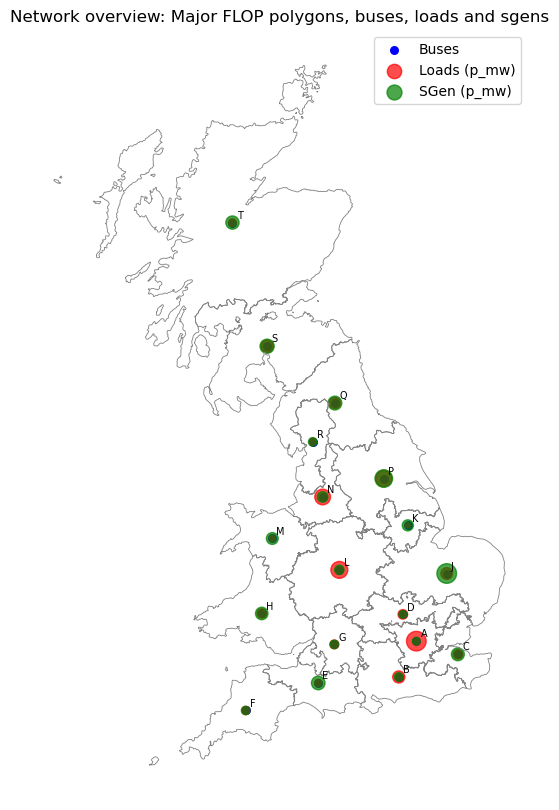

In [145]:
# Plot network: Major FLOP polygons, buses, loads and sgens (with bus name labels)
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Prepare bus GeoDataFrame from net.bus_geodata
if not hasattr(net, 'bus_geodata') or net.bus_geodata.empty:
    raise RuntimeError('No `net.bus_geodata` found. Ensure the network was created.')

bus_geo = net.bus_geodata.copy()
# detect lon/lat columns
if set(['longitude','latitude']).issubset(bus_geo.columns):
    lon = bus_geo['longitude']
    lat = bus_geo['latitude']
elif set(['x','y']).issubset(bus_geo.columns):
    lon = bus_geo['x']
    lat = bus_geo['y']
else:
    lon = bus_geo.iloc[:,0]
    lat = bus_geo.iloc[:,1]

bus_df = pd.DataFrame({'bus': bus_geo.index, 'lon': lon.values, 'lat': lat.values})
# detect coordinate system: if lon values large assume EPSG:27700
if (bus_df['lon'].abs() > 180).any():
    bus_gdf = gpd.GeoDataFrame(bus_df, geometry=gpd.points_from_xy(bus_df.lon, bus_df.lat), crs='EPSG:27700').to_crs('EPSG:4326')
else:
    bus_gdf = gpd.GeoDataFrame(bus_df, geometry=gpd.points_from_xy(bus_df.lon, bus_df.lat), crs='EPSG:4326')

# Attach bus names from net.bus if available
if 'name' in net.bus.columns:
    names_df = pd.DataFrame({'bus': net.bus.index, 'name': net.bus['name'].astype(str).values})
    bus_gdf = bus_gdf.merge(names_df, on='bus', how='left')
else:
    bus_gdf['name'] = bus_gdf['bus'].astype(str)

# Loads GeoDataFrame
loads_gdf = None
if hasattr(net, 'load') and len(net.load) > 0:
    loads = net.load.copy()
    loads = loads.merge(bus_gdf[['bus','geometry']], left_on='bus', right_on='bus', how='left')
    loads_gdf = gpd.GeoDataFrame(loads, geometry='geometry', crs='EPSG:4326')

# Sgens GeoDataFrame
sgens_gdf = None
if hasattr(net, 'sgen') and len(net.sgen) > 0:
    sgens = net.sgen.copy()
    sgens = sgens.merge(bus_gdf[['bus','geometry']], left_on='bus', right_on='bus', how='left')
    sgens_gdf = gpd.GeoDataFrame(sgens, geometry='geometry', crs='EPSG:4326')

# Major FLOP polygons if available
polys = None
if 'major_FLOP_polygons' in globals():
    try:
        polys = major_FLOP_polygons.to_crs('EPSG:4326')
    except Exception:
        polys = major_FLOP_polygons.copy()

# Plot
fig, ax = plt.subplots(1,1, figsize=(12,10))
if polys is not None:
    polys.boundary.plot(ax=ax, color='gray', linewidth=0.6)

# buses
bus_gdf.plot(ax=ax, color='blue', markersize=30, label='Buses')

# annotate bus names with small offset
for _, r in bus_gdf.iterrows():
    if r.geometry is None or r.geometry.is_empty:
        continue
    x, y = r.geometry.x, r.geometry.y
    label = str(r.get('name',''))
    if label:
        ax.annotate(label, xy=(x,y), xytext=(3,3), textcoords='offset points', fontsize=7, color='black')

# loads size scaling
if loads_gdf is not None and 'p_mw' in loads_gdf.columns:
    sizes = (loads_gdf['p_mw'].fillna(0) / max(1, loads_gdf['p_mw'].max())) * 200
    loads_gdf.plot(ax=ax, color='red', markersize=sizes, alpha=0.7, label='Loads (p_mw)')
elif loads_gdf is not None:
    loads_gdf.plot(ax=ax, color='red', markersize=50, alpha=0.7, label='Loads')

# sgens size scaling
if sgens_gdf is not None and 'p_mw' in sgens_gdf.columns:
    sizes = (sgens_gdf['p_mw'].fillna(0) / max(1, sgens_gdf['p_mw'].max())) * 200
    sgens_gdf.plot(ax=ax, color='green', markersize=sizes, alpha=0.7, label='SGen (p_mw)')
elif sgens_gdf is not None:
    sgens_gdf.plot(ax=ax, color='green', markersize=50, alpha=0.7, label='SGen')

ax.set_title('Network overview: Major FLOP polygons, buses, loads and sgens')
ax.set_axis_off()
# Legend
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend()

plt.show()


In [146]:
# Print total generation and total load (from net and aggregated dataframes)
total_sgen = 0.0
if hasattr(net, 'sgen') and len(net.sgen) > 0 and 'p_mw' in net.sgen.columns:
    total_sgen = float(net.sgen['p_mw'].sum())
total_load = 0.0
if hasattr(net, 'load') and len(net.load) > 0 and 'p_mw' in net.load.columns:
    total_load = float(net.load['p_mw'].sum())

# Fallback totals from aggregated dataframes
total_gen_from_df = 0.0
if 'demand_by_nearest_flop' in globals():
    df = demand_by_nearest_flop.copy()
    gen_cols = ['Embedded Solar','Embedded Wind','Embedded Hydro','Embedded Other','Generation Capacity (MW)']
    for c in gen_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)
    total_gen_from_df = float(df[gen_cols].sum().sum())

total_load_from_df = 0.0
if 'demand_by_nearest_flop' in globals() and 'P Gross' in demand_by_nearest_flop.columns:
    total_load_from_df = float(demand_by_nearest_flop['P Gross'].astype(float).sum())
elif 'demand_by_major_flop' in globals() and 'P Gross' in demand_by_major_flop.columns:
    total_load_from_df = float(demand_by_major_flop['P Gross'].astype(float).sum())

print(f'Total static generation (net.sgen p_mw): {total_sgen:.2f} MW')
print(f'Total aggregated generation (from dataframes): {total_gen_from_df:.2f} MW')
print(f'Total load (net.load p_mw): {total_load:.2f} MW')
print(f'Total load (from dataframes P Gross): {total_load_from_df:.2f} MW')

Total static generation (net.sgen p_mw): 115864.50 MW
Total aggregated generation (from dataframes): 115864.50 MW
Total load (net.load p_mw): 56752.33 MW
Total load (from dataframes P Gross): 55968.50 MW


In [147]:
# Display and export bus geodata
import geopandas as gpd
import pandas as pd

if hasattr(net, 'bus_geodata') and net.bus_geodata is not None and len(net.bus_geodata)>0:
    bg = net.bus_geodata.copy()
    # normalize column names
    if set(['x','y']).issubset(bg.columns):
        lon_col, lat_col = 'x','y'
    elif set(['longitude','latitude']).issubset(bg.columns):
        lon_col, lat_col = 'longitude','latitude'
    else:
        # pick first two numeric columns as fallback
        num_cols = [c for c in bg.columns if pd.api.types.is_numeric_dtype(bg[c])]
        if len(num_cols) >= 2:
            lon_col, lat_col = num_cols[0], num_cols[1]
        else:
            lon_col = lat_col = None

    print("net.bus_geodata (raw):")
    display(bg)

    if lon_col and lat_col:
        try:
            gdf = gpd.GeoDataFrame(bg.copy(), geometry=gpd.points_from_xy(bg[lon_col], bg[lat_col]))
            print('\nAs GeoDataFrame (first 10 rows):')
            display(gdf.head(10))
        except Exception as e:
            print('Could not create GeoDataFrame from bus_geodata:', e)

    # attempt to save to CSV in notebook folder
    try:
        out_path = 'bus_geodata.csv'
        bg.to_csv(out_path, index=True)
        print(f"Saved bus geodata to {out_path}")
    except Exception as e:
        print('Could not save bus_geodata.csv:', e)
else:
    print('No net.bus_geodata found or it is empty.')

# Also show bus_gdf if present (Major FLOP centroids)
if 'bus_gdf' in globals():
    print('\nbus_gdf (Major FLOP centroids):')
    try:
        display(bus_gdf.head())
    except Exception:
        print('bus_gdf exists but could not be displayed')

net.bus_geodata (raw):


,longitude,latitude
0,-0.282949,51.558824
1,-0.688969,51.071499
2,0.676585,51.380073
3,-0.594945,51.923131
4,-2.549716,50.990003
5,-4.226170,50.615654
6,-2.177895,51.514502
7,-3.854784,51.935467
8,0.419494,52.479112
9,-0.479862,53.134145



As GeoDataFrame (first 10 rows):


,longitude,latitude,geometry
0,-0.282949,51.558824,POINT (-0.28295 51.55882)
1,-0.688969,51.071499,POINT (-0.68897 51.0715)
2,0.676585,51.380073,POINT (0.67659 51.38007)
3,-0.594945,51.923131,POINT (-0.59494 51.92313)
4,-2.549716,50.990003,POINT (-2.54972 50.99)
5,-4.226170,50.615654,POINT (-4.22617 50.61565)
6,-2.177895,51.514502,POINT (-2.17789 51.5145)
7,-3.854784,51.935467,POINT (-3.85478 51.93547)
8,0.419494,52.479112,POINT (0.41949 52.47911)
9,-0.479862,53.134145,POINT (-0.47986 53.13415)


Saved bus geodata to bus_geodata.csv

bus_gdf (Major FLOP centroids):


,bus,lon,lat,geometry,name
0,0,-0.282949,51.558824,POINT (-0.28295 51.55882),A
1,1,-0.688969,51.071499,POINT (-0.68897 51.0715),B
2,2,0.676585,51.380073,POINT (0.67659 51.38007),C
3,3,-0.594945,51.923131,POINT (-0.59494 51.92313),D
4,4,-2.549716,50.990003,POINT (-2.54972 50.99),E


In [ ]:
# Assign nearest bus to each GSP ID and save results
import geopandas as gpd
import pandas as pd

# Prepare GSP GeoDataFrame
if 'gsp_points' in globals():
    gsp_gdf = gsp_points.copy()
    if 'GSP ID' not in gsp_gdf.columns:
        gsp_gdf = gsp_gdf.reset_index()
else:
    if 'gsp_info_dataframe' in globals():
        gsp_gdf = gsp_info_dataframe.copy()
        if 'GSP ID' not in gsp_gdf.columns:
            gsp_gdf = gsp_gdf.reset_index()
        if 'geometry' not in gsp_gdf.columns:
            gsp_gdf['geometry'] = gpd.points_from_xy(gsp_gdf.Longitude, gsp_gdf.Latitude)
        gsp_gdf = gpd.GeoDataFrame(gsp_gdf, geometry='geometry', crs='EPSG:4326')
    else:
        raise RuntimeError('No `gsp_points` or `gsp_info_dataframe` found in the notebook namespace')

# Prepare bus GeoDataFrame from net.bus_geodata or buses_df
if 'net' in globals() and hasattr(net, 'bus_geodata') and net.bus_geodata is not None and len(net.bus_geodata)>0:
    bg = net.bus_geodata.copy()
    # detect coordinate columns
    if set(['longitude','latitude']).issubset(bg.columns):
        lon_col, lat_col = 'longitude', 'latitude'
    elif set(['x','y']).issubset(bg.columns):
        lon_col, lat_col = 'x','y'
    else:
        num_cols = [c for c in bg.columns if pd.api.types.is_numeric_dtype(bg[c])]
        if len(num_cols) >= 2:
            lon_col, lat_col = num_cols[0], num_cols[1]
        else:
            raise RuntimeError('`net.bus_geodata` found but no coordinate columns detected')

    # Create bus GeoDataFrame using those coordinates and attach bus names if available
    bus_coords = bg[[lon_col, lat_col]].copy()
    bus_coords.columns = ['lon','lat']
    bus_coords['bus_index'] = bus_coords.index
    # Try to get names from net.bus
    if 'name' in net.bus.columns:
        bus_coords['name'] = net.bus['name'].values
    else:
        bus_coords['name'] = bus_coords['bus_index'].astype(str)

    # detect CRS: if lon values large assume EPSG:27700
    if (bus_coords['lon'].abs() > 180).any():
        bus_crs = 'EPSG:27700'
    else:
        bus_crs = 'EPSG:4326'

    bus_gdf = gpd.GeoDataFrame(bus_coords, geometry=gpd.points_from_xy(bus_coords['lon'], bus_coords['lat']), crs=bus_crs)
else:
    if 'buses_df' in globals():
        bus_gdf = gpd.GeoDataFrame(buses_df.copy(), geometry=gpd.points_from_xy(buses_df.longitude, buses_df.latitude), crs='EPSG:4326')
        bus_gdf = bus_gdf.rename(columns={'name':'name'})
    else:
        raise RuntimeError('No bus geodata found: provide `net.bus_geodata` or `buses_df`')

# Project both to metric CRS (EPSG:27700) for distance calculation
try:
    gsp_proj = gsp_gdf.to_crs(epsg=27700)
except Exception:
    gsp_proj = gsp_gdf.copy()
    if gsp_proj.crs is None:
        gsp_proj.crs = 'EPSG:4326'
    gsp_proj = gsp_proj.to_crs(epsg=27700)

try:
    bus_proj = bus_gdf.to_crs(epsg=27700)
except Exception:
    bus_proj = bus_gdf.copy()
    if bus_proj.crs is None:
        bus_proj.crs = 'EPSG:4326'
    bus_proj = bus_proj.to_crs(epsg=27700)

# Prepare minimal bus table for join
if 'name' in bus_proj.columns:
    bus_for_join = bus_proj[['name','geometry']].rename(columns={'name':'Closest_Bus'})
else:
    bus_for_join = bus_proj[['bus_index','geometry']].copy()
    bus_for_join['Closest_Bus'] = bus_for_join['bus_index'].astype(str)
    bus_for_join = bus_for_join[['Closest_Bus','geometry']]

# Spatial join: nearest bus with distance in metres
nearest = gpd.sjoin_nearest(gsp_proj, bus_for_join, how='left', distance_col='Closest_Bus_dist_m')

# Ensure GSP ID column exists
if 'GSP ID' not in nearest.columns:
    nearest = nearest.reset_index()

nearest = nearest[['GSP ID','Closest_Bus','Closest_Bus_dist_m']]

# Merge results back into original gsp_points (preserve original CRS/geometry)
try:
    gsp_out = gsp_gdf.reset_index().merge(nearest, on='GSP ID', how='left')
except Exception:
    # fallback: merge on reset index name
    gsp_out = gsp_gdf.reset_index().merge(nearest, left_on=gsp_gdf.reset_index().columns[0], right_on='GSP ID', how='left')

# Add km column for readability
gsp_out['Closest_Bus_dist_km'] = gsp_out['Closest_Bus_dist_m'] / 1000.0

print('Nearest bus for each GSP (first 20 rows):')
display(gsp_out[['GSP ID','Closest_Bus','Closest_Bus_dist_m','Closest_Bus_dist_km']].head(20))

# Save to CSV
out_path = 'gsp_nearest_bus.csv'
try:
    gsp_out[['GSP ID','Closest_Bus','Closest_Bus_dist_m','Closest_Bus_dist_km']].to_csv(out_path, index=False)
    print(f'Saved nearest-bus table to {out_path}')
except Exception as e:
    print('Could not save CSV:', e)

# Also create a mapping dict in Python for quick lookup
gsp_to_bus = dict(zip(gsp_out['GSP ID'], gsp_out['Closest_Bus']))
print('Created `gsp_to_bus` dict in the notebook namespace')